## Data Visualization with Python

Python provides various libraries that come with different features for visualizing data. All these libraries come with different features and can support various types of graphs. In this tutorial, we will be discussing four such libraries
- Matplotlib
- Seaborn
- Bokeh
- Plotly  

We will discuss these libraries one by one and will plot some most commonly used graphs.  

**Note:** If you want to learn in-depth information about these libraries you can follow their complete tutorial.  

Before diving into these libraries, at first, we will need a database to plot the data. We will be using the `tips database` for this complete tutorial. Let's discuss see a brief about this database.

## Database Used  

**Tips Database**  

Tips database is the record of the tip given by the customers in a restaurant for two and a half months in the early 1990s. It contains 6 columns such as total_bill, sex, smoker, day, time, size.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:

# reading the database
data_df = pd.read_csv('tips.csv')

data_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [7]:
data_df.isna().count()

total_bill    244
tip           244
sex           244
smoker        244
day           244
time          244
size          244
dtype: int64

I see that there are no null values across the data set.

In [17]:
data_df.groupby(['sex', 'smoker'])['total_bill'].size().unstack()

# .unstack() takes the rows and converts them into the columns headers.

smoker,No,Yes
sex,,
Female,54,33
Male,97,60


**.unstack()** pivots a row index level to become column headers

In [18]:
sex_smoker_bill_count = data.groupby(['sex', 'smoker'])['total_bill'].size().unstack()
sex_smoker_bill_count

smoker,No,Yes
sex,,
Female,54,33
Male,97,60


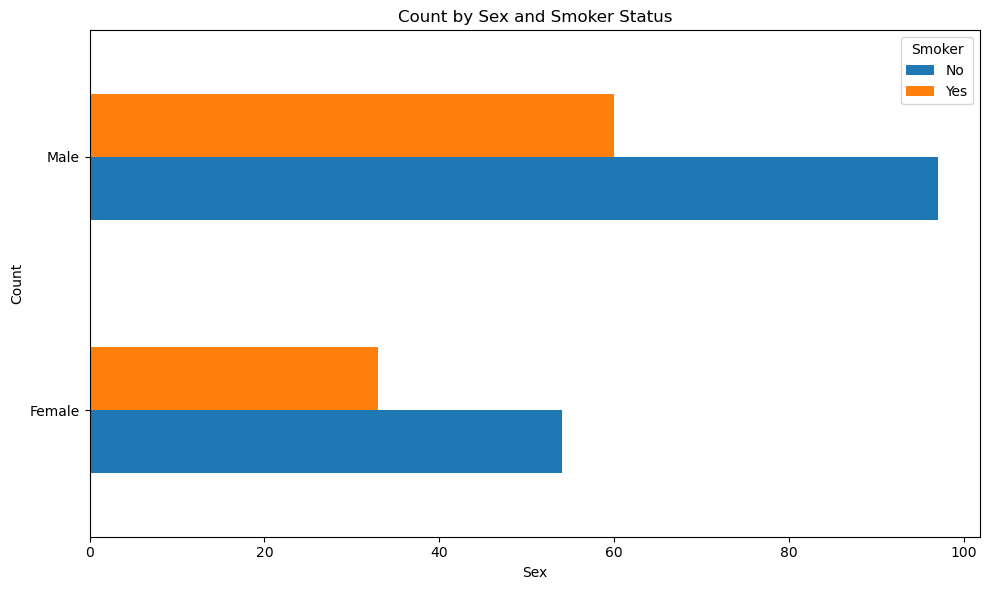

In [19]:
# Plot
sex_smoker_bill_count.plot(kind='barh', figsize=(10,6))
plt.title('Count by Sex and Smoker Status')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Smoker')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

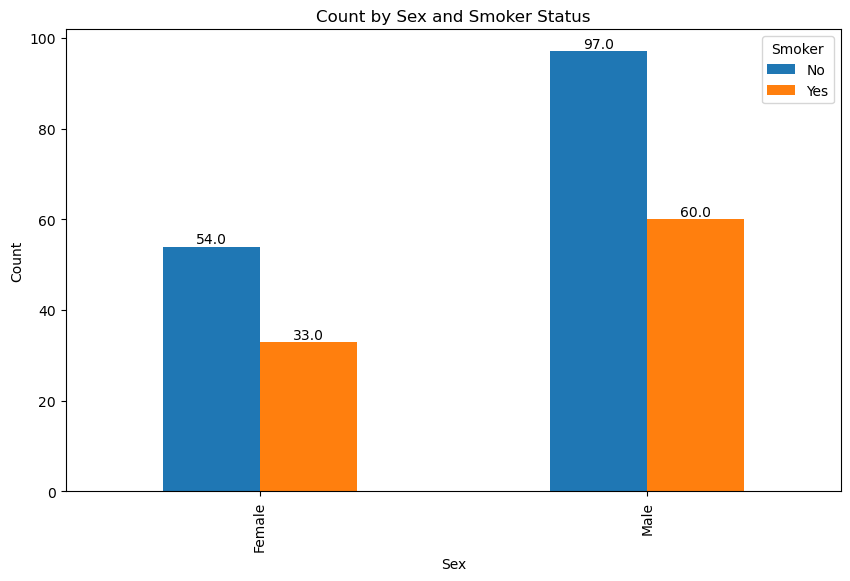

In [21]:
dataplot = sex_smoker_bill_count

ax = dataplot.plot(kind='bar', figsize=(10,6))
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')
    
plt.title('Count by Sex and Smoker Status')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Smoker');

## Matplotlib  

Matplotlib is an easy-to-use, low-level data visualization libraty that is built on Numpy arrays. It consists of various plots like scatter plot, line plot, histogram, etc. Matplotlib provides a lot of flexibility.

## Scatter Plot  

Scatter plots are used to observe relationships between variables and uses dots to represent the relationship between them. The `scatter()` method in the matplotlib library is used to draw a scatter plot.

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [7]:
data.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [8]:
data.groupby('day')['total_bill'].max()

day
Fri     40.17
Sat     50.81
Sun     48.17
Thur    43.11
Name: total_bill, dtype: float64

**boxplot**

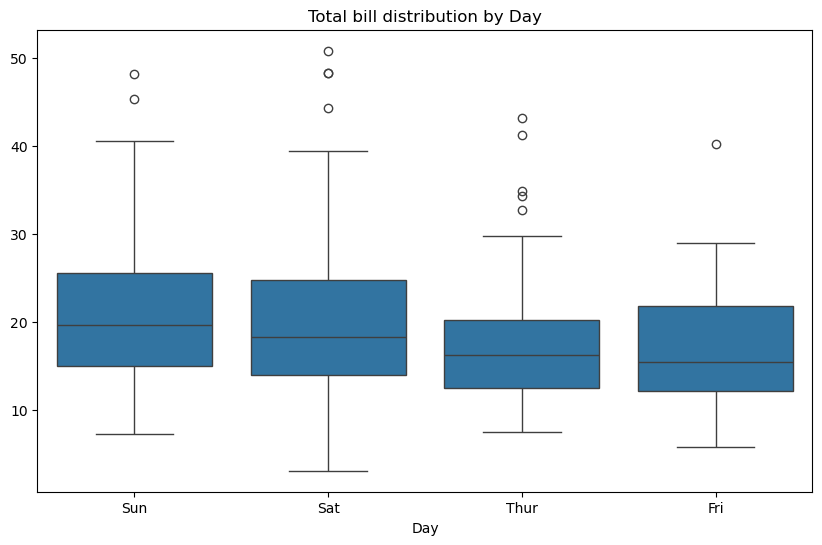

In [9]:
plt.figure(figsize=(10,6))
sns.boxplot(x='day', y='total_bill', data=data)
plt.xlabel('Day')
plt.ylabel(None)
plt.title('Total bill distribution by Day')
plt.show()

In [10]:
data['tip'].describe()

count    244.000000
mean       2.998279
std        1.383638
min        1.000000
25%        2.000000
50%        2.900000
75%        3.562500
max       10.000000
Name: tip, dtype: float64

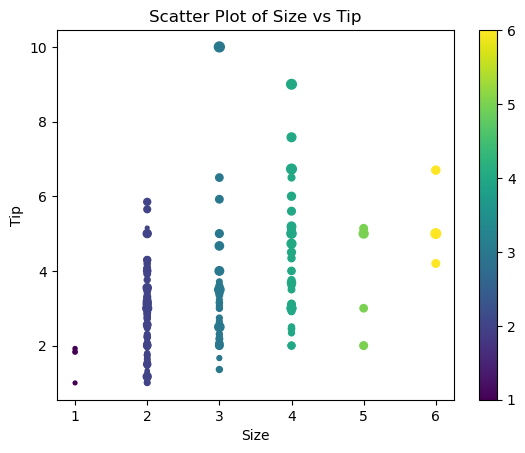

In [11]:
# c=data['size'] -> color of the points
# s=data['total_bill'] -> size of the points
plt.scatter(data['size'], data['tip'], c=data['size'], s=data['total_bill'])
plt.xlabel('Size')
plt.ylabel('Tip')
plt.title('Scatter Plot of Size vs Tip')
plt.colorbar();

In [12]:
flowers_df = sns.load_dataset('iris')
flowers_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


<Axes: xlabel='sepal_length', ylabel='sepal_width'>

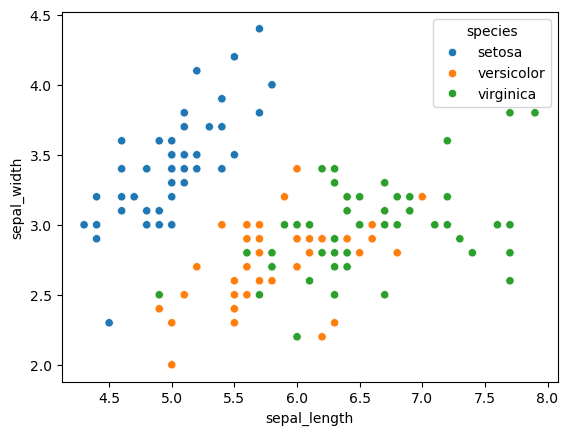

In [13]:
sns.scatterplot(x='sepal_length', y='sepal_width', hue='species', data=flowers_df)

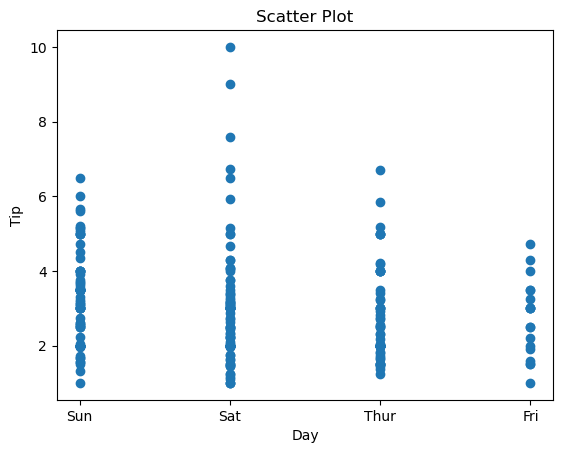

In [14]:
plt.scatter(data['day'], data['tip'])
plt.title('Scatter Plot')
plt.xlabel('Day')
plt.ylabel('Tip');

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


This graph can be more meaningful if we can add colors and also change the size of the points. We can do this by using the `c and s` parameter respectively of the scatter function. We can also show the color bar using the `colorbar()` method.

In [16]:
data['tip'].max()

np.float64(10.0)

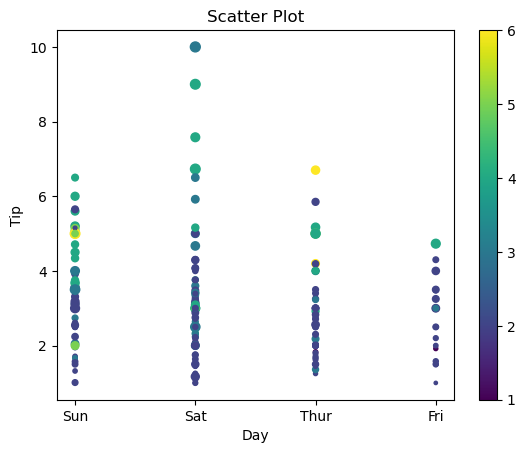

In [17]:
# Scatter plot with day against tip
plt.scatter(data['day'], data['tip'], c=data['size'], s=data['total_bill'])
plt.title('Scatter Plot')
plt.xlabel('Day')
plt.ylabel('Tip')
plt.colorbar();

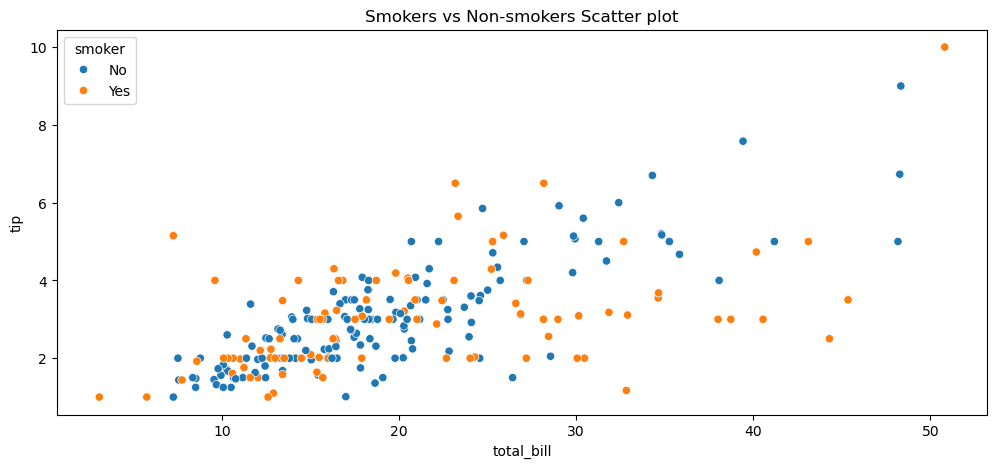

In [19]:
plt.figure(figsize=(12,5))
sns.scatterplot(x='total_bill', y='tip', data=data, hue='smoker')
plt.title('Smokers vs Non-smokers Scatter plot');

In [20]:
data

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [21]:
data.time.unique()

array(['Dinner', 'Lunch'], dtype=object)

In [28]:
day_count = data.groupby('day')[['tip', 'total_bill']].count().unstack()
type(day_count)

pandas.core.series.Series

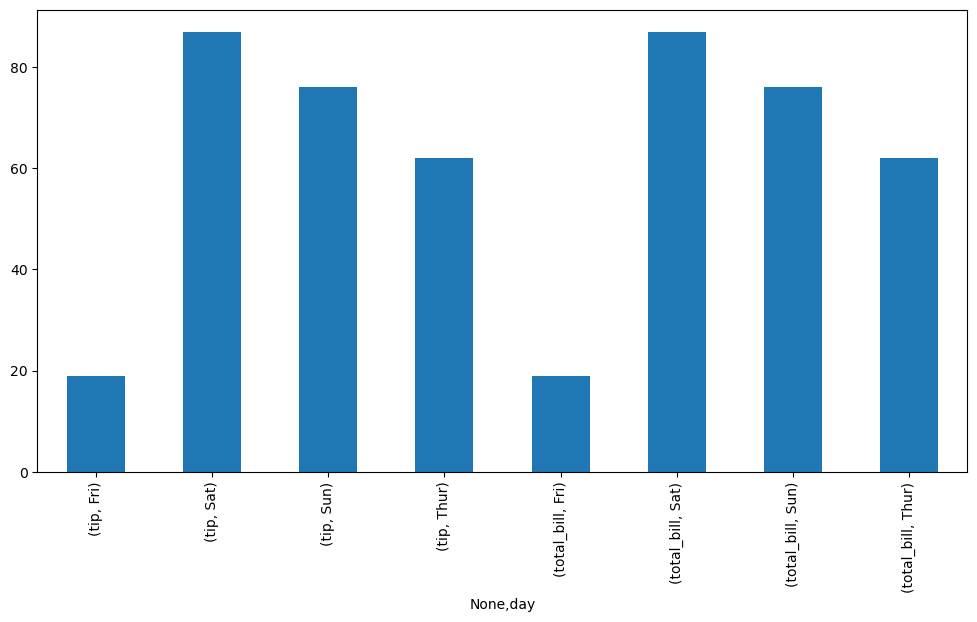

In [29]:
day_count.plot(kind='bar', figsize=(12,6));

In [33]:
day_count = data.groupby('day')['tip'].count()
type(day_count)

pandas.core.series.Series

In [34]:
day_count.reset_index()
type(day_count)

pandas.core.series.Series

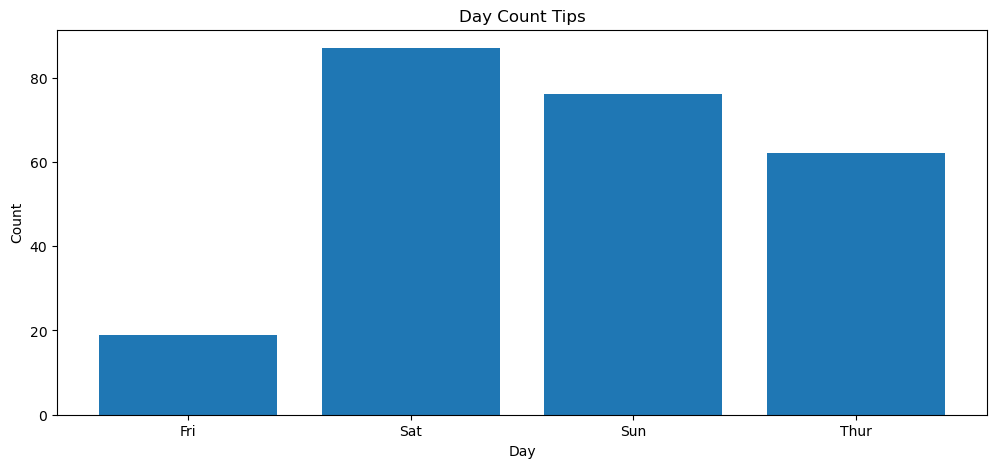

In [35]:
plt.figure(figsize=(12,5))
plt.bar(day_count.index, day_count.values)
plt.xlabel('Day')
plt.ylabel('Count')
plt.title('Day Count Tips');

## Line Chart  

Line Chart is used to represent a relationship between two data X and Y on different axis. It is plotted using the `plot()` function. Let's see an example.

In [36]:
len(data['size'])

244

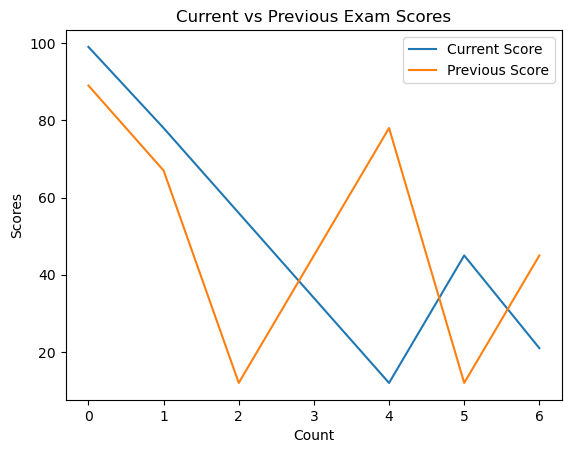

In [37]:
current_scores = [99, 78, 56, 34, 12, 45, 21]
previous_scores = [89, 67, 12, 45, 78, 12, 45]

plt.plot(current_scores)
plt.plot(previous_scores)
plt.title('Current vs Previous Exam Scores')
plt.xlabel('Count')
plt.ylabel('Scores')
plt.legend(['Current Score', 'Previous Score']);

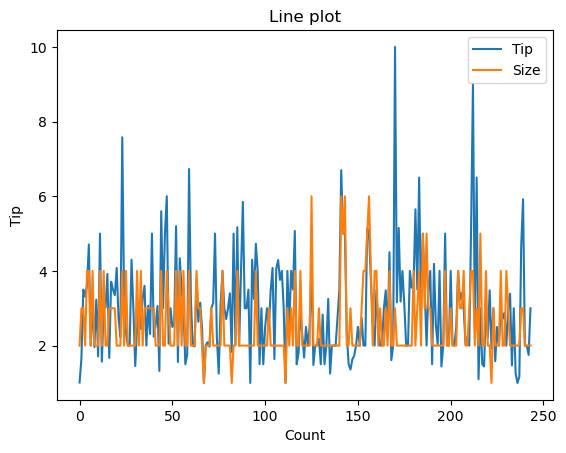

In [38]:
# Scatter plot with day against tip
plt.plot(data['tip'])
plt.plot(data['size'])

plt.title('Line plot')
plt.xlabel('Count')
plt.ylabel('Tip')
plt.legend(['Tip', 'Size']);

In [42]:
data

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


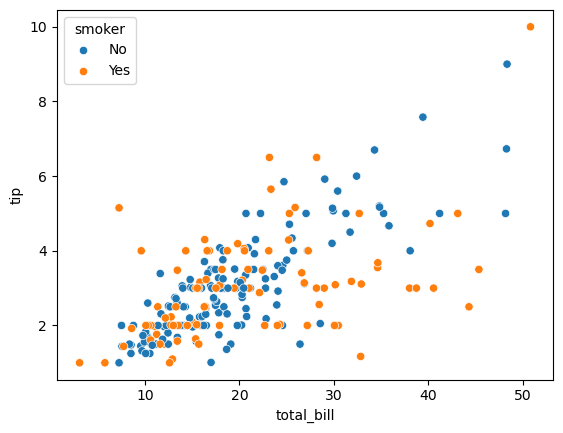

In [43]:
sns.scatterplot(x='total_bill', y='tip', hue='smoker', data=data);

In [44]:
data['size'].unique()

array([2, 3, 4, 1, 6, 5])

## Bar Chart  

A bar plot or bar chart is a graph that represents the category of data with rectangular bars with lengths and heights that is proportional to the values which they represent. It can be created using the `bar()` method.

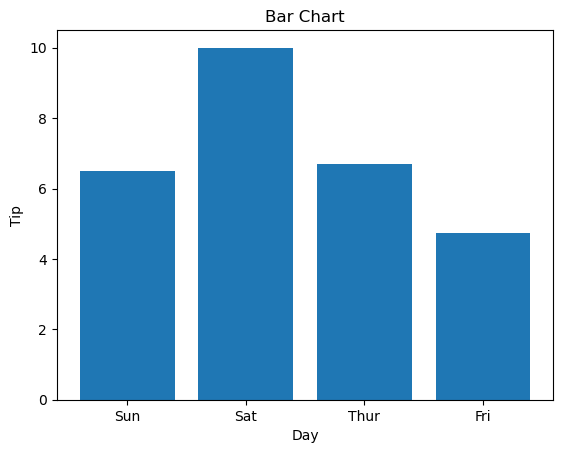

In [45]:
# Bar chart with day against tip
plt.bar(data['day'], data['tip'])

plt.title('Bar Chart')
plt.xlabel('Day')
plt.ylabel('Tip')
plt.show();

## Histogram  

A `histogram` is basically used to represent data in the form of some groups. It is a type of bar plot where the X-axis represents the bin ranges while the Y-axix gives information about frequency. The `hist()` function is used to compute and create a histogram. In histogram, if we pass categorial data then it will automatically compute the frequecy of that data i.e. how often each value occured.

In [50]:
data['total_bill'].max()

np.float64(50.81)

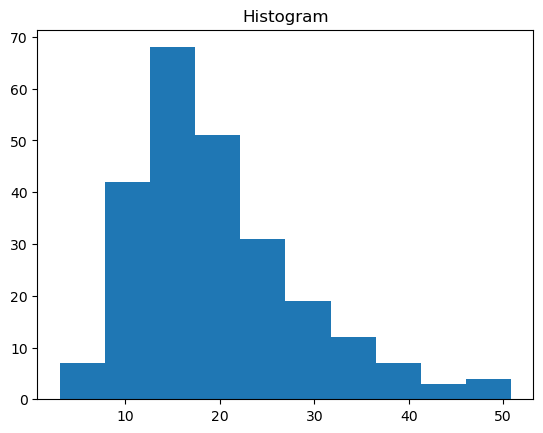

In [47]:
# histogram of total_bills
plt.hist(data['total_bill'])

plt.title('Histogram')
# Adding the legends
plt.show()

## Seaborn  

**Seaborn** is a high-level interface built on top of the Matplotlib. It provides beautiful design styles and color palettes to make more attractive graphs.  

Seaborn is built on top of Matplotlib, therefore it can be used with the Matplotlib as well. Using both Matplotlib and Seaborn together is a very simple process. We just have to invoke the Seaborn Plotting function as normal, and then we can use Matplotlib's customization function.

In [51]:
# importing packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [52]:
data = pd.read_csv('tips.csv')

In [53]:
data

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


**.reset_index()** converts the index of a DataFrame/Series into a regular column and creates a new default integer index (0, 1, 2, ...).

In [59]:
grouped_data = data.groupby(['sex', 'smoker'])['total_bill'].size().reset_index()
grouped_data

,sex,smoker,total_bill
0,Female,No,54
1,Female,Yes,33
2,Male,No,97
3,Male,Yes,60


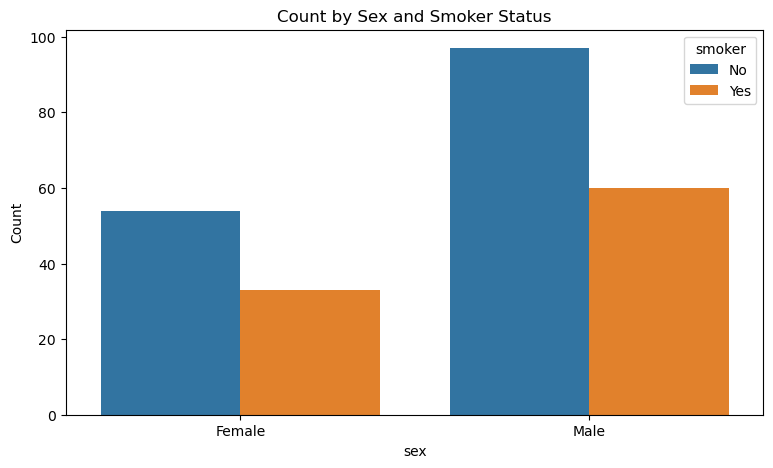

In [61]:
plt.figure(figsize=(9,5))
sns.barplot(x='sex', y='total_bill', hue='smoker', data=grouped_data)
plt.ylabel('Count')
plt.title('Count by Sex and Smoker Status')
plt.show()

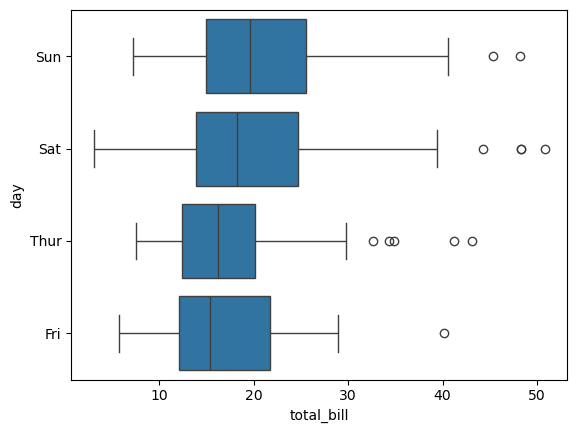

In [64]:
sns.boxplot(x='total_bill', y='day', data=data);

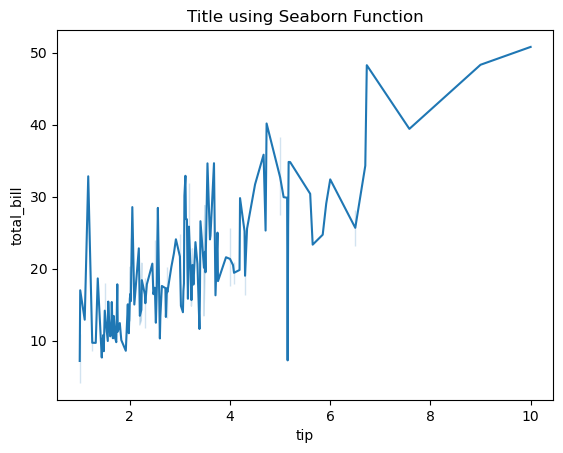

In [68]:
# importing packages
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# reading the database
data = pd.read_csv('tips.csv')

# draw lineplot
sns.lineplot(x='tip', y='total_bill', data=data)

# setting the title using Matplotlib
plt.title('Title using Seaborn Function')

plt.show()

## Scatter Plot  

`Scatter plot` is plotted using the **scatterplot()** method. This is similar to Matplotlib, but additional argument data is required.

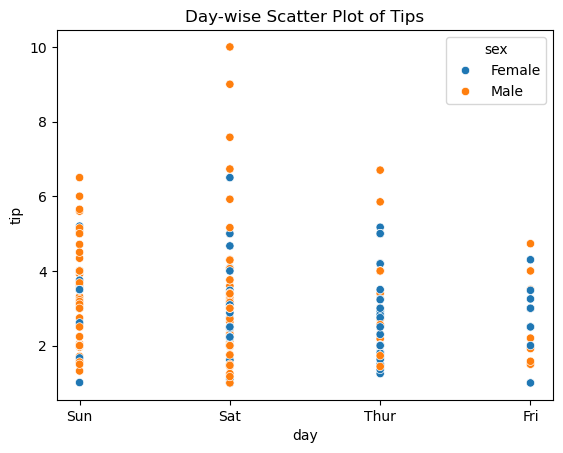

In [71]:
plt.title('Day-wise Scatter Plot of Tips')
sns.scatterplot(x='day', y='tip', data=data, hue='sex')
plt.show()

You will find that while using Matplotlib you will have a lot difficult if you want to color each point of this plot according to the sex. But in scatter plot it can be done with the help of **hue** argument.

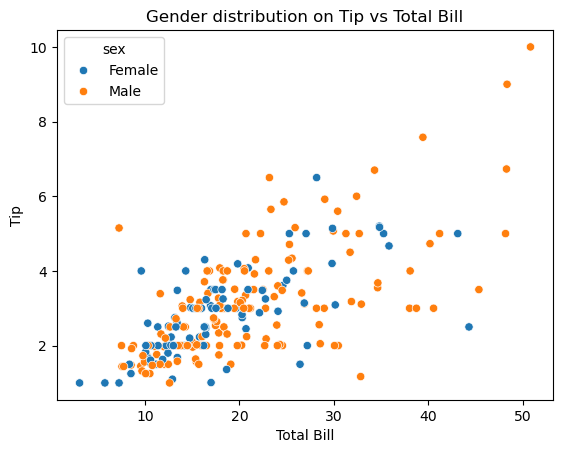

In [73]:
plt.title('Gender distribution on Tip vs Total Bill')
sns.scatterplot(x='total_bill', y='tip', data=data, hue='sex')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.show()

## Line Plot  

**Line Plot** in Seaborn plotted using the **lineplot()** method. In this, we can pass only the data argument also.

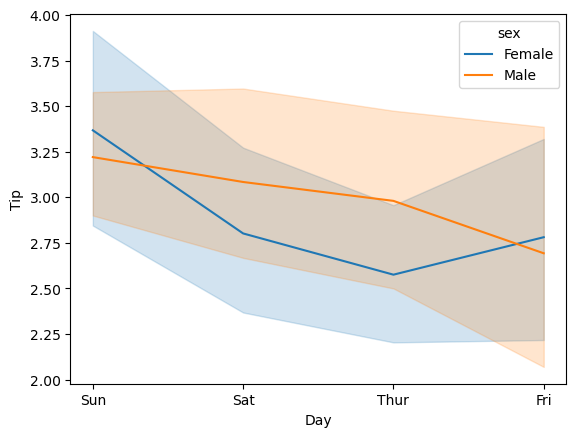

In [76]:
sns.lineplot(x='day', y='tip', data=data, hue='sex')
plt.xlabel('Day')
plt.ylabel('Tip')
plt.show()

In [77]:
data

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


## Select Specific Columns

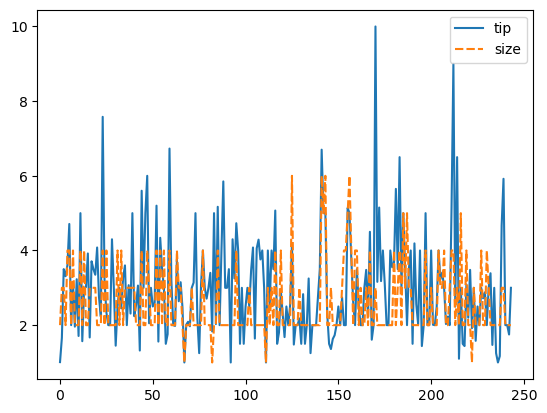

In [81]:
# Plot only specific columns you want
sns.lineplot(data=data[['tip', 'size', 'day']]);

## Plot Individual Columns

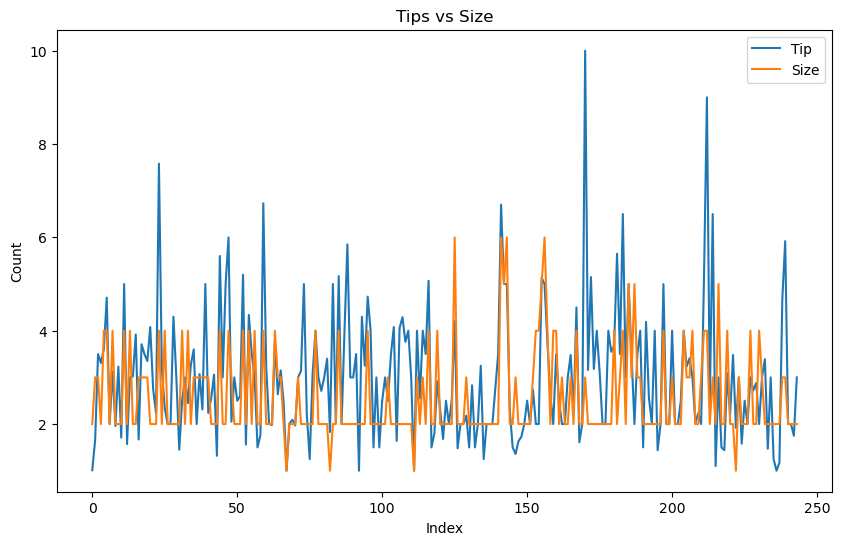

In [ ]:
# Plot each Column seperately
plt.figure(figsize=(10,6))
sns.lineplot(data['tip'], label='Tip')
sns.lineplot(data['size'], label='Size')

plt.xlabel('Index')
plt.ylabel('Count')

plt.title('Tips vs Size')
plt.legend();

##  Plot with Different Colors

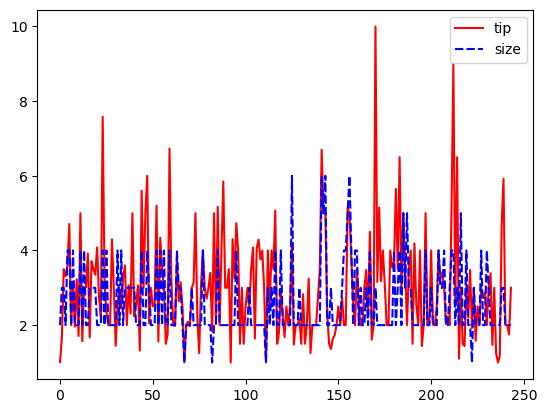

In [82]:
# Custom colors for each line
palette = {'tip': 'red', 'size': 'blue', 'day': 'green'}
sns.lineplot(data.drop(['total_bill'], axis=1), palette=palette);

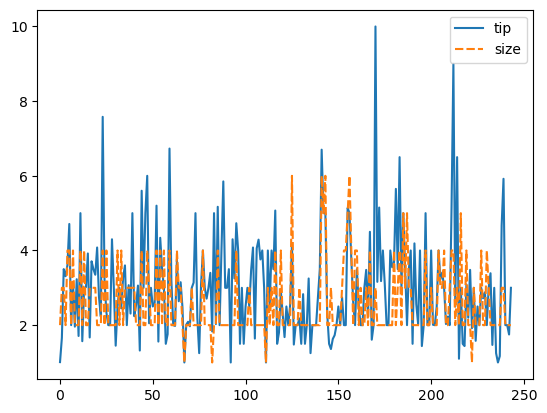

In [ ]:
# using only data attribute

# This drops 'total_bill' column and plots all remaining numeric columns.
sns.lineplot(data=data.drop(['total_bill'], axis=1))
plt.show()

## Bar Plot  

**Bar Plot** in Seaborn can be created using the **barplot()** method.

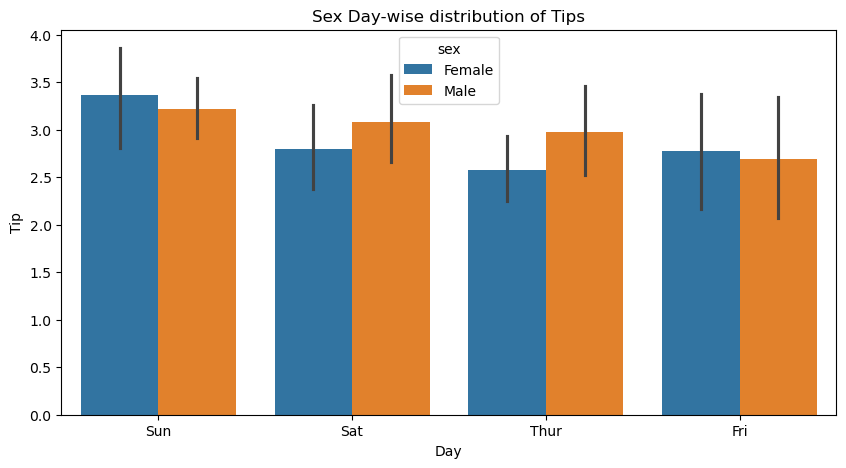

In [84]:
plt.figure(figsize=(10,5))
sns.barplot(x='day', y='tip', hue='sex', data=data)
plt.xlabel('Day')
plt.ylabel('Tip')
plt.title('Sex Day-wise distribution of Tips');

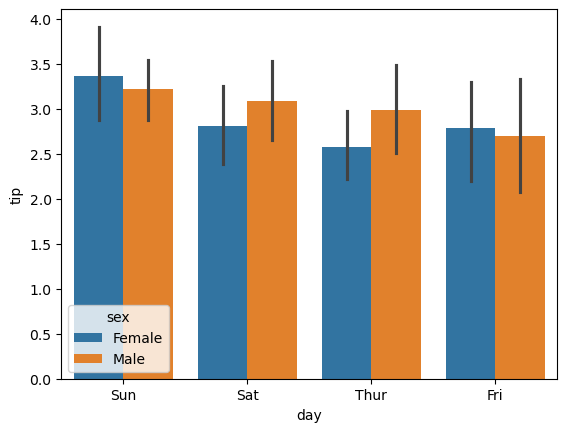

In [83]:
sns.barplot(x='day', y='tip', data=data, hue='sex')
plt.show()

## Histogram  

The histogram in Seaborn can be plotted using the **histplot()** function.

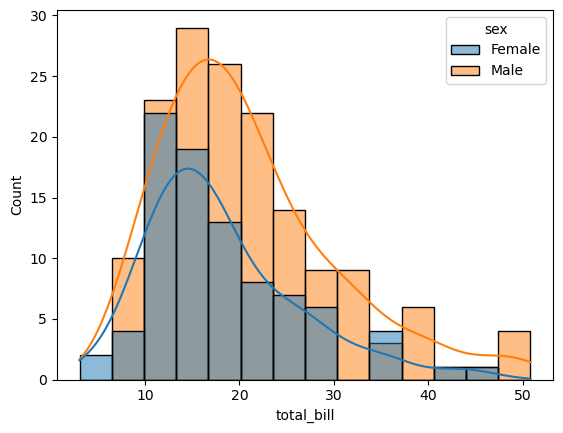

In [85]:
sns.histplot(x='total_bill', data=data, kde=True, hue='sex')
plt.show()

After going through all these plots you must have noticed that customizing plots using Seaborn is a lot more easier than using Matplotlib. And it is also built over matplotlib then we can also use matplotlib functions while using Seaborn.

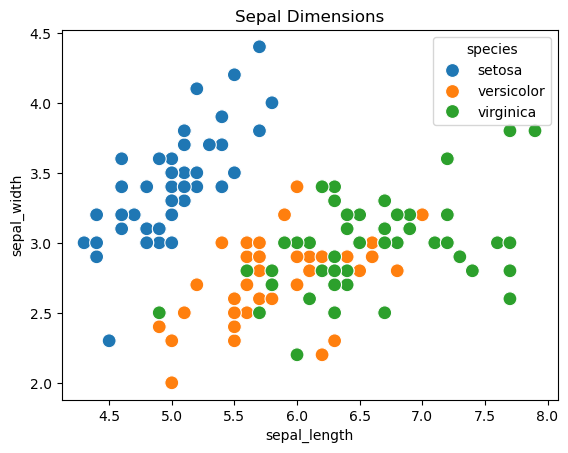

In [86]:
# Plotting using Pandas Data Frames
plt.title('Sepal Dimensions')
sns.scatterplot(x='sepal_length', y='sepal_width', hue='species', data=flowers_df, s=100);

In [87]:
flowers_df.sepal_width

0      3.5
1      3.0
2      3.2
3      3.1
4      3.6
      ... 
145    3.0
146    2.5
147    3.0
148    3.4
149    3.0
Name: sepal_width, Length: 150, dtype: float64

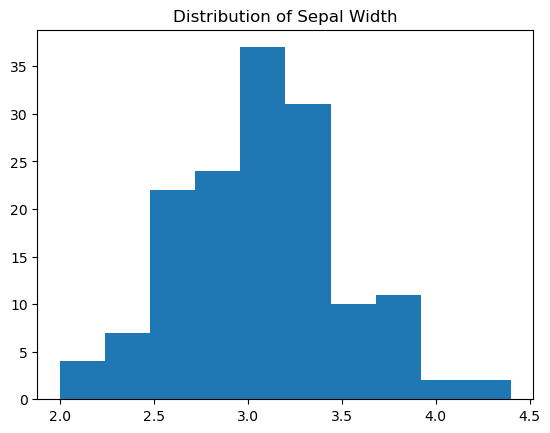

In [89]:
plt.title('Distribution of Sepal Width')
plt.hist(flowers_df.sepal_width);

## Bokeh  

Let's move on to the third library of our list. Bokeh is mainly famous for its interactive charts visualization. Bokeh renders its plots using HTML and JavaScript that uses modern web browsers for presenting elegant, concise construction of novel graphics with high-level interactivity.

## Scatter Plot  

`Scatter Plot` in Bokeh can be plotted using the scatter() method of the plotting module. Here pass the x and y coordinates respectively.

In [ ]:
from bokeh.plotting import figure, output_file, show
from bokeh.palettes import magma

# Create output file
output_file("scatter_plot.html")

# Instantiate the figure
graph = figure(title='Bokeh Scatter Graph: Total Bill vs Tip')

# Plot with a single color
graph.scatter(data['total_bill'], data['tip'], 
              color='navy', 
              size=8, 
              alpha=0.6)

# Show the plot
show(graph)

In [ ]:
# importing the modules
from bokeh.plotting import figure, output_file, show
from bokeh.palettes import magma

# instatiating the figure object
graph = figure(title='Bokeh Scatter Graph')

color = magma(244)

# plotting the graph
graph.scatter(data['total_bill'], data['tip'], color=color)

# displaying the model
show(graph)

## Line Chart  

A **line plot** can be created using the line() method of the plotting module.

In [ ]:
# Count of each unique value of tip column
df = data['tip'].value_counts()

# plotting the graph
graph.line(df, data['tip'])

# displaying the model
show(graph)

## Bar Chart  

Bar Chart can be of two types horizontal bars and vertical bars. Each can be created using the hbar() and vbar() fuctions of the plotting interface respectively.

In [ ]:
# plotting the graph
graph.vbar(data['total_bill'], top=data['tip'])

show(graph)

## Ploty  

This is the last library of our list and you might be wondering why plotly. Here's why -
- Plotly has hover too capabilities that allow us to detect any outliers or anomalies in numerous data points
- It allows more customization
- It makes the graph visually more attractive

## Scatter Plot  

**Scatter plot** in Plotly can be created using the **scatter()** method of plotly.express. Like Seaborn, an extra data argument is also required here.

In [ ]:
import plotly.express as px

# plotting the scatter chart
fig = px.scatter(data, x='day', y='tip', color='sex')

# showing the plot
fig.show()

## Line Chart  

**Line plot** in Plotly is much accessible and illustrious annexation to plotly which manage a variety of types of data and assemble easy-to-style statistic. With **px.line** each data position is represented as a vertex.

In [ ]:
data.groupby('sex')['tip'].plot(kind='line')
plt.legend(['female', 'male'])
plt.xlabel('index')
plt.ylabel('tip');

In [ ]:
data.groupby('sex')['tip'].describe()

In [ ]:
# plotting the scatter chart
fig = px.line(data, y='tip', color='sex')

fig.show()

## Bar Chart  

Bar Chart in Plotly can be created using the bar() method of plotly.express class.

In [ ]:
# plotting the scatter chart
fig = px.bar(data, x='day', y='tip', color='sex')

fig.show()

## Histogram  

In plotly, **histograms** can be created using the histogram() function of the plotly.express class.

In [ ]:
# plotting the scatter chart
fig = px.histogram(data, x='total_bill', color='sex')

fig.show()

## Adding interaction  

Just like Bokeh, plotly also provides various interaction. Let's discuss a few of them.  

**Creating Dropdown Menu:** A drop-down menu is a part of the menu-button which is displayed on a screen all the time. Every menu button is associated with a Menu widget that can display the choices for that menu button when clicked on it. In plotly, there are 4 possible methods to modify the charts by using updatemenu method. 
- **restlyle:** modify data or data attributes
- **relayout:** modify layout attributes
- **update:** modify data and layout attributes
- **animate:** start or pause an animation

In [ ]:
import plotly.graph_objects as px
import pandas as pd

# reading the database
data = pd.read_csv('tips.csv')

plot = px.Figure(data=[px.Scatter(
    x=data['day'],
    y=data['tip'],
    mode='markers'
)])

# Add dropdown
plot.update_layout(
    updatemenus=[
        dict(
            buttons=list([
                dict(
                    args=['type', 'scatter'],
                    label='Scatter Plot',
                    method='restyle'
                ),
                dict(
                    args=['type', 'bar'],
                    label='Bar Chart',
                    method='restyle'
                )
            ]),
            direction='down'
        ),
    ]
)

plot.show()

**Adding Buttons:** In plotly, actions custom Buttons are used to quickly make actions directly from a record. Custom Buttons can be added to page layouts in CRM, Marketing, and Custom Apps. There are also 4 possible methods that can be applied in custom buttons:
- **restyle:** modify data or data attributes
- **relayout:** modify layout attributes
- **update:** modify data and layout attributes
- **animate:** start or pause an animation

In [ ]:
plot = px.Figure(data=[px.Scatter(
    x=data['day'],
    y=data['tip'],
    mode='markers'
)])

# Add dropdown
plot.update_layout(
    updatemenus=[
        dict(
            type='buttons',
            direction='left',
            buttons=list([
                dict(
                    args=['type'],
                    label='Sctter Plot',
                    method='restyle'
                ),
                dict(
                    args=['type', 'bar'],
                    label='Bar Chart',
                    method='restyle'
                )
            ]),
        ),
    ]
)

plot.show()

## Creating Sliders and Selectors:  

In plotly, the range slider is a custom range-type input control. It allows selecting a value or a range of values between a specified minimum and maximum range. And the range selector is a tool for selectinh ranges to display within the chart. It provides buttons to select pre-configured ranges in the chart. It also provied input boxes where the minimum and maximum dates can be manually input

In [ ]:
plot = px.Figure(data=[px.Scatter(
    y=data['tip'],
    mode='lines',
)])

plot.update_layout(
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(
                    count=1,
                    step='day',
                    stepmode='backward'
                )
            ]),
            rangeslider=dict(visible=True)
        ),
    )
)

plot.show()

## Conclusion  

In this tutorial, we have plotted the tips dataset with the help of the four different plotting modules of Python namely Matplotlib, Seaborn, Bokeh, and Plotly. Each module showed the plot in its own unique way and each one has its own set of features like Matplotlib provides more flexibility but at the cost of writing more code whereas Seaborn being a high-level language provides allows one to achieve the same goal with a small depending on the task we want to do.